# Customer Churn Prediction
Predicting whether a telecom customer will churn (leave) using account, demographic, and service-usage data.

**Dataset:** Telco Customer Churn (7,043 customers, 21 features)
**Models compared:** Logistic Regression, Decision Tree, Random Forest


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report)
import joblib

sns.set_style('whitegrid')
%matplotlib inline

## 2. Load the Data

In [2]:
df = pd.read_csv('data/telco_churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Data Cleaning

In [4]:
# TotalCharges is loaded as object due to blank strings for new customers -> convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Drop rows with missing TotalCharges (very few rows, new customers with 0 tenure)
df = df.dropna(subset=['TotalCharges'])

# customerID is just an identifier, not predictive
df = df.drop('customerID', axis=1)

print("Duplicates:", df.duplicated().sum())
print("Shape after cleaning:", df.shape)

Missing values:
 TotalCharges    11
dtype: int64
Duplicates: 22
Shape after cleaning: (7032, 20)


## 4. Exploratory Data Analysis (EDA)

### 4a. Target distribution

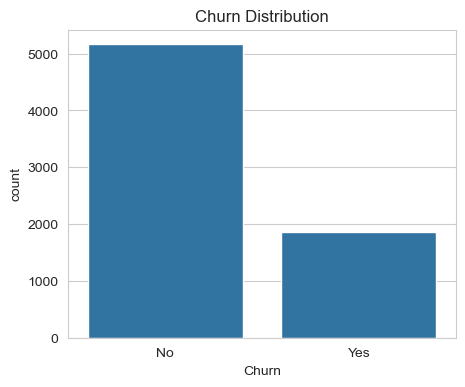

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True))

### 4b. Numerical features vs churn

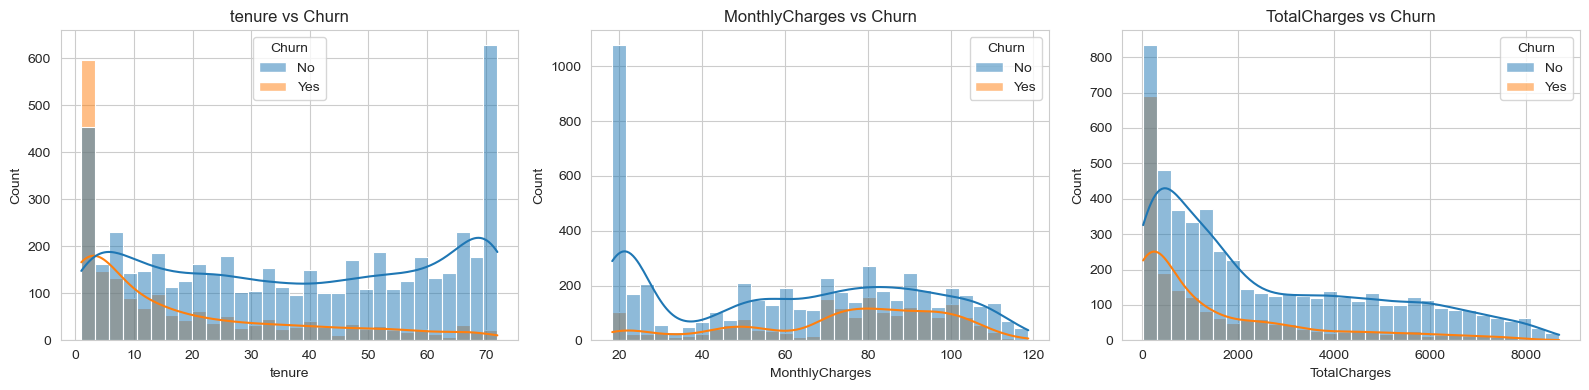

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, bins=30, ax=ax)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

### 4c. Categorical features vs churn

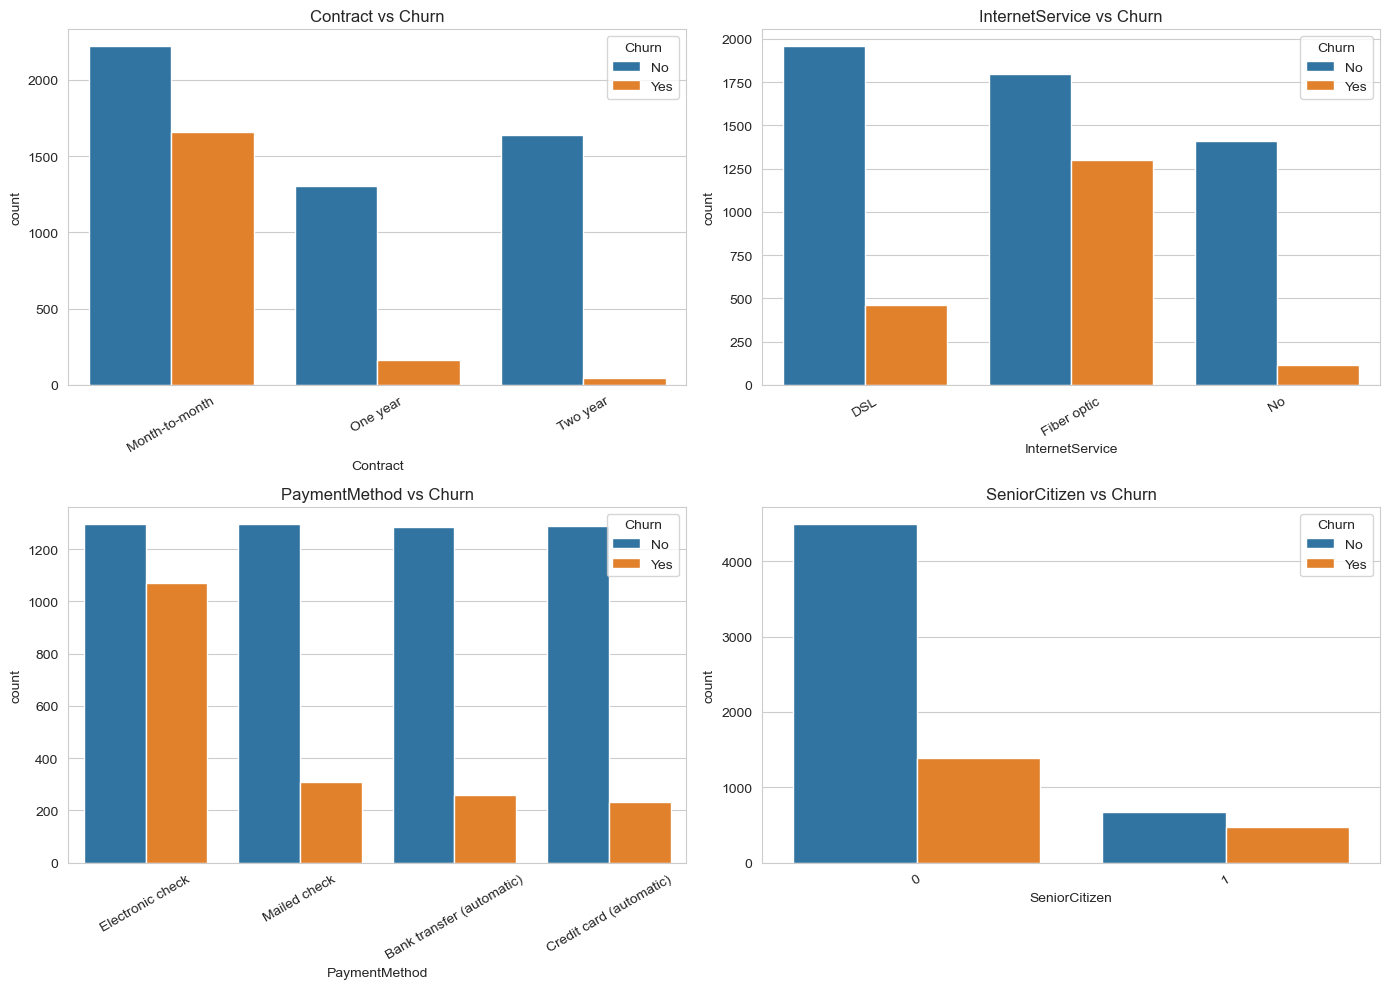

In [7]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=ax)
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

### 4d. Correlation among numeric features

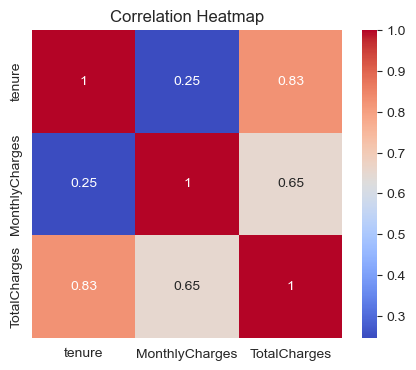

In [8]:
plt.figure(figsize=(5,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Key EDA findings (fill in after you run this on your own):**
- Month-to-month contract customers churn far more than 1-2 year contract customers
- Low tenure combined with high monthly charges is a strong churn signal
- Fiber optic internet service customers show higher churn than DSL


## 5. Feature Engineering

In [9]:
# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# New feature: average charge per month of tenure
df['AvgChargePerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

# Bucket tenure
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                             labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])

# Binary Yes/No columns -> 0/1
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# One-hot encode remaining categorical columns
df = pd.get_dummies(df, columns=['gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_group'],
    drop_first=True)

print(df.shape)
df.head()

(7032, 36)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,AvgChargePerMonth,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-2yr,tenure_group_2-4yr,tenure_group_4-5yr,tenure_group_5-6yr
0,0,1,0,1,0,1,29.85,29.85,0,14.925000,...,False,False,False,False,True,False,False,False,False,False
1,0,0,0,34,1,0,56.95,1889.50,0,53.985714,...,False,True,False,False,False,True,False,True,False,False
2,0,0,0,2,1,1,53.85,108.15,1,36.050000,...,False,False,False,False,False,True,False,False,False,False
3,0,0,0,45,0,0,42.30,1840.75,0,40.016304,...,False,True,False,False,False,False,False,True,False,False
4,0,0,0,2,1,1,70.70,151.65,1,50.550000,...,False,False,False,False,True,False,False,False,False,False


## 6. Train-Test Split & Scaling

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'AvgChargePerMonth']
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (5625, 35)  Test shape: (1407, 35)


## 7. Train Models

### Model 1: Logistic Regression

In [11]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

### Model 2: Decision Tree

In [12]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

### Model 3: Random Forest

In [13]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

## 8. Evaluate & Compare Models

In [14]:
def evaluate(name, y_test, y_pred, model, X_test):
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }

results = pd.DataFrame([
    evaluate("Logistic Regression", y_test, y_pred_lr, log_reg, X_test),
    evaluate("Decision Tree", y_test, y_pred_dt, dt, X_test),
    evaluate("Random Forest", y_test, y_pred_rf, rf, X_test),
])
results = results.sort_values('F1', ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.797441,0.642173,0.537433,0.585153,0.837824
1,Decision Tree,0.786070,0.612308,0.532086,0.569385,0.817320
2,Random Forest,0.790334,0.633898,0.500000,0.559043,0.833822


### Confusion matrices

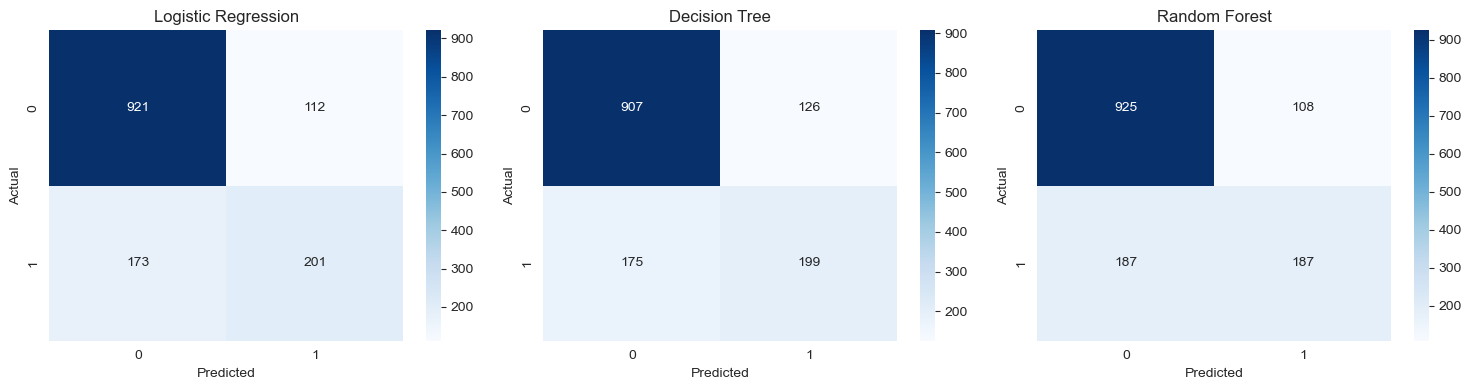

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, (name, pred) in zip(axes, [("Logistic Regression", y_pred_lr),
                                     ("Decision Tree", y_pred_dt),
                                     ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Random Forest)

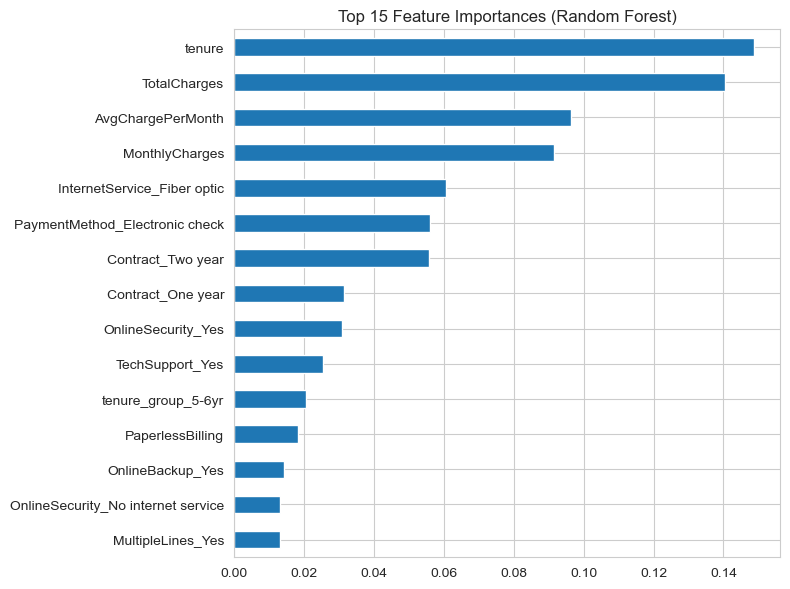

In [16]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(8,6))
importances.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Handle Class Imbalance (Optional Improvement)

In [17]:
rf_balanced = RandomForestClassifier(n_estimators=200, max_depth=10,
                                      class_weight='balanced', random_state=42)
rf_balanced.fit(X_train, y_train)
y_pred_rf_bal = rf_balanced.predict(X_test)

print("Random Forest (balanced) Recall:", recall_score(y_test, y_pred_rf_bal))
print("Random Forest (original) Recall:", recall_score(y_test, y_pred_rf))

Random Forest (balanced) Recall: 0.7459893048128342
Random Forest (original) Recall: 0.5


## 11. Save Best Model

In [18]:
joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.


## 12. Summary

- **Best model:** (fill in based on your `results` table above — usually Random Forest)
- **Key churn drivers:** Contract type, tenure, monthly charges (see feature importance plot)
- **Business takeaway:** Target month-to-month, low-tenure, high-monthly-charge customers with retention offers
- **Next steps:** Try XGBoost/LightGBM, hyperparameter tuning with GridSearchCV, deploy via Streamlit
